In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
np.random.seed(42)

X0 = np.random.randn(50,2) + [-2,-2]
X1 = np.random.randn(50,2)+[2,2]

X = np.vstack((X0,X1))
# First 50 points will be class 0 and next 50 will be class 1
y = np.array([0]*50 + [1]*50)

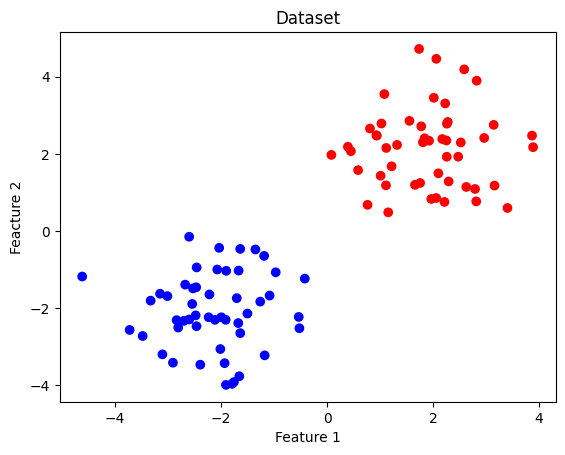

In [3]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr')
plt.xlabel("Feature 1")
plt.ylabel('Feacture 2')
plt.title("Dataset")
plt.show()

In [ ]:
def euclidean_distance(a,b): 

    # here (a-b) substracts coordinates and then square each value after add them and then square root
    return np.sqrt(np.sum((a-b)**2))

In [ ]:
# predict the class for new data point 
# X_train - training feature , y_train - training label , x_test - new test point 
def predict_knn(X_train, y_train, x_test, k=3):
    
    # empty array to store distance from test point to every training point
    distances = []
    
    for i in range(len(X_train)):
        # giving test point and other training points to find distance
        d = euclidean_distance(x_test, X_train[i])
        distances.append(d) # add distance in empty list 
    
    distances = np.array(distances) # its sorts the distances 
    
    # here argsort - returns indices of sorted distances and take first k indices
    k_indices = distances.argsort()[:k]
    
    # this will select labels of nearest neighbors
    k_labels = y_train[k_indices]
    
    # here np.bincount - counts occurrences and then argmax - will give highest count 
    prediction = np.bincount(k_labels).argmax()
    
    return prediction

In [6]:
x_new = np.array([0,0])

prediction = predict_knn(X, y, x_new, k=3)

print("Predicted class:", prediction)

Predicted class: 1


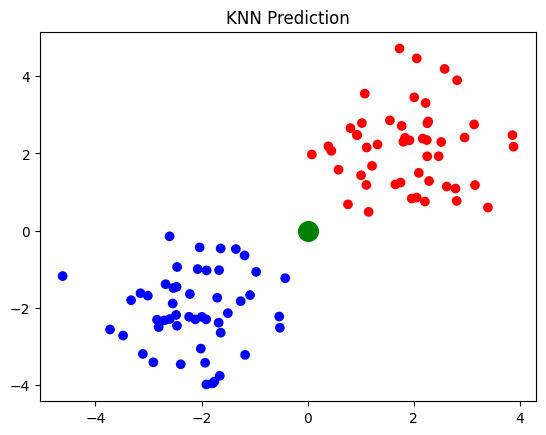

In [7]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.scatter(x_new[0], x_new[1], c='green', s=200)
plt.title("KNN Prediction")
plt.show()

In [8]:
X_test = np.array([
    [0,0],
    [-3,-3],
    [3,3],
    [1,-1]
])

for point in X_test:
    pred = predict_knn(X, y, point, k=3)
    print("Point:", point, "Predicted class:", pred)

Point: [0 0] Predicted class: 1
Point: [-3 -3] Predicted class: 0
Point: [3 3] Predicted class: 1
Point: [ 1 -1] Predicted class: 1
